In [1]:
!pip install ultralytics -q

import os, json, shutil, random, numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

BASE_SAVE_DIR    = '/content/drive/MyDrive/recaptcha dataset with rare samples'
drive_zip        = os.path.join(BASE_SAVE_DIR, 'recaptcha-dataset-master.zip')
DATASET_ROOT     = '/content/recaptcha-dataset-master'
TRAIN_DIR        = os.path.join(DATASET_ROOT, 'Training')
VAL_DIR          = os.path.join(DATASET_ROOT, 'Validation')
WEIGHTS_BACKUP   = os.path.join(BASE_SAVE_DIR, 'tractor_runs_backup')
os.makedirs(WEIGHTS_BACKUP, exist_ok=True)

if not os.path.isdir(DATASET_ROOT):
    print('Extracting dataset...')
    with zipfile.ZipFile(drive_zip, 'r') as z:
        z.extractall('/content')
    print('Done.')
else:
    print('Dataset already extracted.')

MODEL_SRC = os.path.join(BASE_SAVE_DIR, 'classification_model.pt')
MODEL_DST = '/content/classification_model.pt'
if not os.path.exists(MODEL_DST):
    shutil.copy(MODEL_SRC, MODEL_DST)

print('Setup complete.')
print(f'Weights backup dir: {WEIGHTS_BACKUP}')

Mounted at /content/drive
Extracting dataset...
Done.
Setup complete.
Weights backup dir: /content/drive/MyDrive/recaptcha dataset with rare samples/tractor_runs_backup


In [3]:
# ── Build val-only evaluation set + baseline ──────────────────────────────
ALL_CLASSES = ['Bicycle', 'Boat', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
               'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm',
               'Stairs', 'Taxi', 'Tractor', 'Traffic Light']

val_only_images = []
for cls in ALL_CLASSES:
    cls_dir = os.path.join(VAL_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for f in sorted(os.listdir(cls_dir)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            val_only_images.append((os.path.join(cls_dir, f), cls))

print(f'Val-only set: {len(val_only_images)} images')

print('\nEvaluating baseline model...')
base_model = YOLO('/content/classification_model.pt')
base_correct_val = sum(1 for img_path, true_cls in val_only_images
                       if base_model.names[base_model(img_path, verbose=False)[0].probs.top1] == true_cls)
base_acc_val = base_correct_val / len(val_only_images) * 100
print(f'  Baseline (val only): {base_acc_val:.1f}% ({base_correct_val}/{len(val_only_images)})')

Val-only set: 759 images

Evaluating baseline model...
  Baseline (val only): 83.1% (631/759)


In [4]:
# ── Dataset Preparation ────────────────────────────────────────────────────
EXISTING_CLASSES = ['Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
                    'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm',
                    'Stairs', 'Traffic Light']
NEW_CLASS = 'Tractor'
N_VAL     = 5
N_SEEDS   = 10
N_VALUES  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

src_train = TRAIN_DIR
orig_val  = VAL_DIR

tractor_all = sorted(os.listdir(os.path.join(src_train, NEW_CLASS)))
max_train = len(tractor_all) - N_VAL
print(f'{NEW_CLASS}: {len(tractor_all)} total, hold out {N_VAL} for val, max train = {max_train}')

classes_missing_val = [cls for cls in EXISTING_CLASSES
                       if not os.path.isdir(os.path.join(orig_val, cls))]
if classes_missing_val:
    print(f'Classes missing Validation folder: {classes_missing_val}')

total = 0
for n in N_VALUES:
    for seed in range(N_SEEDS):
        rng = random.Random(seed)
        shuffled = tractor_all.copy()
        rng.shuffle(shuffled)
        val_imgs   = shuffled[:N_VAL]
        train_imgs = shuffled[N_VAL:N_VAL + n]

        out = f'/content/tractor_er_n{n}_seed{seed}'
        if os.path.exists(out):
            shutil.rmtree(out)

        for cls in EXISTING_CLASSES:
            imgs = sorted(os.listdir(os.path.join(src_train, cls)))
            rng_cls = random.Random(seed)
            rng_cls.shuffle(imgs)
            dst = os.path.join(out, 'train', cls)
            os.makedirs(dst)
            for img in imgs[:n]:
                shutil.copy(os.path.join(src_train, cls, img), os.path.join(dst, img))

        dst = os.path.join(out, 'train', NEW_CLASS)
        os.makedirs(dst)
        for img in train_imgs:
            shutil.copy(os.path.join(src_train, NEW_CLASS, img), os.path.join(dst, img))

        for cls in EXISTING_CLASSES:
            cls_val_src = os.path.join(orig_val, cls)
            if os.path.isdir(cls_val_src):
                dst = os.path.join(out, 'val', cls)
                shutil.copytree(cls_val_src, dst)
            else:
                cls_train_imgs = sorted(os.listdir(os.path.join(src_train, cls)))
                train_used = set(os.listdir(os.path.join(out, 'train', cls)))
                val_pool = [f for f in cls_train_imgs if f not in train_used]
                dst = os.path.join(out, 'val', cls)
                os.makedirs(dst)
                for img in val_pool[:15]:
                    shutil.copy(os.path.join(src_train, cls, img), os.path.join(dst, img))

        dst = os.path.join(out, 'val', NEW_CLASS)
        os.makedirs(dst)
        for img in val_imgs:
            shutil.copy(os.path.join(src_train, NEW_CLASS, img), os.path.join(dst, img))

        total += 1

    sample_dir = f'/content/tractor_er_n{n}_seed0/train'
    total_imgs = sum(len(os.listdir(os.path.join(sample_dir, c))) for c in os.listdir(sample_dir))
    print(f'  N={n:>2}: {total_imgs} train images')

print(f'\nTotal datasets created: {total}')

Tractor: 20 total, hold out 5 for val, max train = 15
Classes missing Validation folder: ['Stairs']
  N= 1: 14 train images
  N= 2: 28 train images
  N= 3: 42 train images
  N= 4: 56 train images
  N= 5: 70 train images
  N= 6: 84 train images
  N= 7: 98 train images
  N= 8: 112 train images
  N= 9: 126 train images
  N=10: 140 train images
  N=12: 167 train images
  N=15: 206 train images

Total datasets created: 120


In [5]:
# ── Training (with weight backup to Drive after each run) ────────────────────────
RUNS_DIR = '/content/runs'
total_runs = len(N_VALUES) * N_SEEDS
done = 0

for n in N_VALUES:
    print(f'\n{"="*55}')
    print(f'  N={n}  ({N_SEEDS} seeds)')
    print(f'{"="*55}')

    for seed in range(N_SEEDS):
        data_dir = f'/content/tractor_er_n{n}_seed{seed}'
        run_name = f'tractor_er_n{n}_seed{seed}'

        for cf in Path(data_dir).glob('**/*.cache'):
            cf.unlink()

        # Skip if last.pt already exists in backup
        # Use last.pt, not best.pt, to avoid data-leakage
        backup_last = f'{WEIGHTS_BACKUP}/{run_name}/weights/last.pt'
        if os.path.exists(backup_last):
            done += 1
            print(f'  seed={seed} skipped (already in backup)  ({done}/{total_runs})')
            continue

        model = YOLO('/content/classification_model.pt')
        model.train(
            data     = data_dir,
            epochs   = 50,
            imgsz    = 128,
            batch    = 16,
            lr0      = 0.0005,
            freeze   = 5,
            project  = RUNS_DIR,
            name     = run_name,
            exist_ok = True,
            verbose  = False,
            hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
            degrees=15, translate=0.1, scale=0.5,
            fliplr=0.5, flipud=0.0,
            erasing=0.4,
            auto_augment='randaugment',
        )

        # Backup last.pt to Drive (we don't use best.pt, so don't bother backing it up)
        src = f'{RUNS_DIR}/{run_name}/weights/last.pt'
        dst_dir = f'{WEIGHTS_BACKUP}/{run_name}/weights'
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(src, f'{dst_dir}/last.pt')

        done += 1
        print(f'  seed={seed} done  ({done}/{total_runs})  [last.pt backed up]')

print(f'\nAll {total_runs} runs complete.')


  N=1  (10 seeds)
  seed=0 skipped (already in backup)  (1/120)
  seed=1 skipped (already in backup)  (2/120)
  seed=2 skipped (already in backup)  (3/120)
  seed=3 skipped (already in backup)  (4/120)
  seed=4 skipped (already in backup)  (5/120)
  seed=5 skipped (already in backup)  (6/120)
  seed=6 skipped (already in backup)  (7/120)
  seed=7 skipped (already in backup)  (8/120)
  seed=8 skipped (already in backup)  (9/120)
  seed=9 skipped (already in backup)  (10/120)

  N=2  (10 seeds)
  seed=0 skipped (already in backup)  (11/120)
  seed=1 skipped (already in backup)  (12/120)
  seed=2 skipped (already in backup)  (13/120)
  seed=3 skipped (already in backup)  (14/120)
  seed=4 skipped (already in backup)  (15/120)
  seed=5 skipped (already in backup)  (16/120)
  seed=6 skipped (already in backup)  (17/120)
  seed=7 skipped (already in backup)  (18/120)
  seed=8 skipped (already in backup)  (19/120)
  seed=9 skipped (already in backup)  (20/120)

  N=3  (10 seeds)
  seed=0 ski

In [6]:
# ── Evaluate with last.pt (val-only) ───────────────────────────────────────────
print('Evaluating with last.pt (val-only)...\n')

last_recall = {n: [] for n in N_VALUES}
last_val    = {n: [] for n in N_VALUES}

for n in N_VALUES:
    for seed in range(N_SEEDS):
        # Try local first, fall back to Drive backup
        w_local  = f'{RUNS_DIR}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w_backup = f'{WEIGHTS_BACKUP}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w = w_local if os.path.exists(w_local) else w_backup
        if not os.path.exists(w):
            print(f'  Missing: {w_local} and {w_backup}')
            continue

        model = YOLO(w)

        # Tractor recall on held-out 5
        val_dir  = f'/content/tractor_er_n{n}_seed{seed}/val/Tractor'
        val_imgs = [os.path.join(val_dir, f) for f in os.listdir(val_dir)]
        cls_idx  = [k for k, v in model.names.items() if v == 'Tractor'][0]
        correct  = sum(1 for p in val_imgs
                       if model(p, verbose=False)[0].probs.top1 == cls_idx)
        last_recall[n].append(correct / len(val_imgs) * 100)

        # Existing-class accuracy on val
        correct_val = sum(1 for img_path, true_cls in val_only_images
                          if model.names[model(img_path, verbose=False)[0].probs.top1] == true_cls)
        last_val[n].append(correct_val / len(val_only_images) * 100)

    rm, rs = np.mean(last_recall[n]), np.std(last_recall[n])
    fm, fs = np.mean(last_val[n]),    np.std(last_val[n])
    print(f'  N={n:>2}: Tractor recall={rm:.1f}% +/- {rs:.1f}%, '
          f'Existing-class={fm:.1f}% +/- {fs:.1f}%')

# Save results to Drive
results = {
    'baseline_val':  base_acc_val,
    'val_eval_size': len(val_only_images),
    'last_recall':   {str(k): v for k, v in last_recall.items()},
    'last_val':      {str(k): v for k, v in last_val.items()},
}
save_path = os.path.join(BASE_SAVE_DIR, 'tractor_lastpt_val_only.json')
with open(save_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved: {save_path}')

Evaluating with last.pt (val-only)...

  N= 1: Tractor recall=2.0% +/- 6.0%, Existing-class=72.5% +/- 1.6%
  N= 2: Tractor recall=36.0% +/- 30.7%, Existing-class=73.9% +/- 2.4%
  N= 3: Tractor recall=70.0% +/- 24.1%, Existing-class=75.3% +/- 2.3%
  N= 4: Tractor recall=66.0% +/- 23.7%, Existing-class=75.2% +/- 1.5%
  N= 5: Tractor recall=74.0% +/- 12.8%, Existing-class=75.9% +/- 1.2%
  N= 6: Tractor recall=86.0% +/- 12.8%, Existing-class=74.8% +/- 1.1%
  N= 7: Tractor recall=80.0% +/- 12.6%, Existing-class=76.9% +/- 1.0%
  N= 8: Tractor recall=82.0% +/- 14.0%, Existing-class=76.6% +/- 1.7%
  N= 9: Tractor recall=84.0% +/- 12.0%, Existing-class=76.6% +/- 1.4%
  N=10: Tractor recall=84.0% +/- 8.0%, Existing-class=77.1% +/- 1.7%
  N=12: Tractor recall=84.0% +/- 12.0%, Existing-class=77.8% +/- 1.4%
  N=15: Tractor recall=88.0% +/- 9.8%, Existing-class=77.8% +/- 1.2%

Saved: /content/drive/MyDrive/recaptcha dataset with rare samples/tractor_lastpt_val_only.json


Tractor (last.pt, val-only)  |  Baseline existing-class: 83.1%

   N |    Tractor recall |   Existing-class acc |   Forgetting
-----------------------------------------------------------------
   1 |    2.0% +/-  6.0% |   72.5% +/-  1.6%   |    +10.6 pp
   2 |   36.0% +/- 30.7% |   73.9% +/-  2.4%   |     +9.2 pp
   3 |   70.0% +/- 24.1% |   75.3% +/-  2.3%   |     +7.9 pp
   4 |   66.0% +/- 23.7% |   75.2% +/-  1.5%   |     +7.9 pp
   5 |   74.0% +/- 12.8% |   75.9% +/-  1.2%   |     +7.2 pp
   6 |   86.0% +/- 12.8% |   74.8% +/-  1.1%   |     +8.3 pp
   7 |   80.0% +/- 12.6% |   76.9% +/-  1.0%   |     +6.3 pp
   8 |   82.0% +/- 14.0% |   76.6% +/-  1.7%   |     +6.6 pp
   9 |   84.0% +/- 12.0% |   76.6% +/-  1.4%   |     +6.5 pp
  10 |   84.0% +/-  8.0% |   77.1% +/-  1.7%   |     +6.0 pp
  12 |   84.0% +/- 12.0% |   77.8% +/-  1.4%   |     +5.3 pp
  15 |   88.0% +/-  9.8% |   77.8% +/-  1.2%   |     +5.3 pp



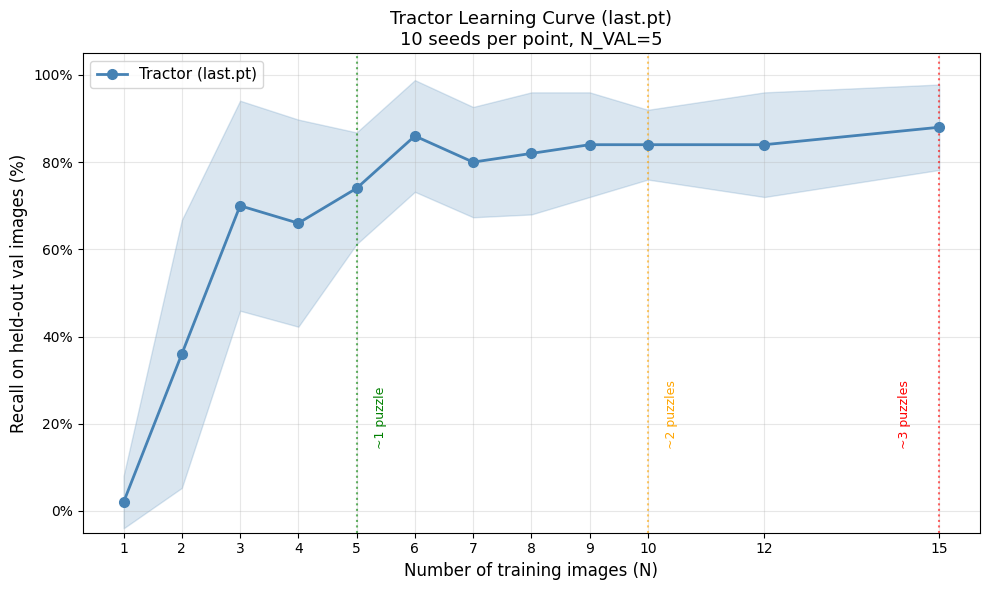

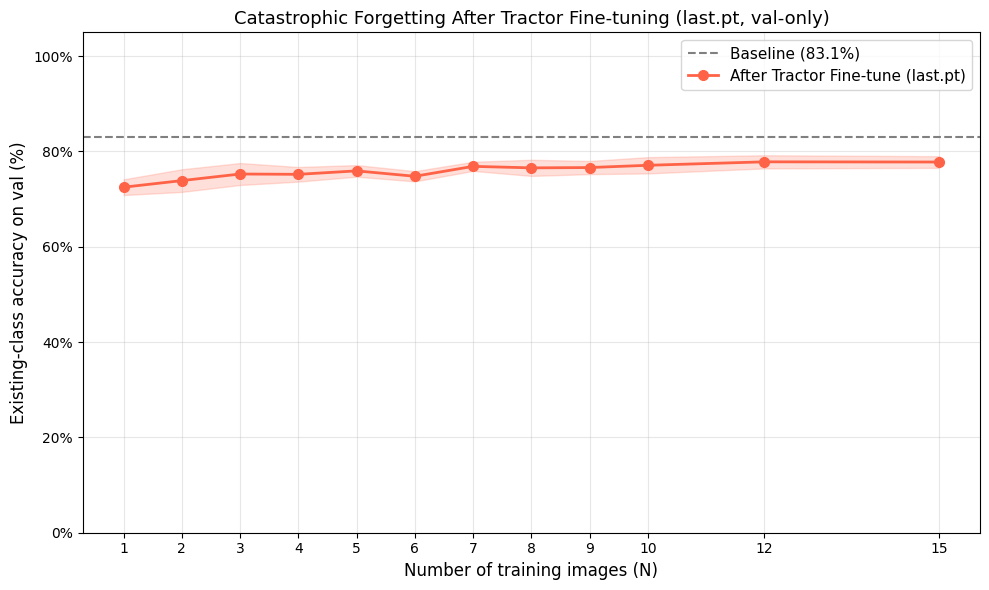

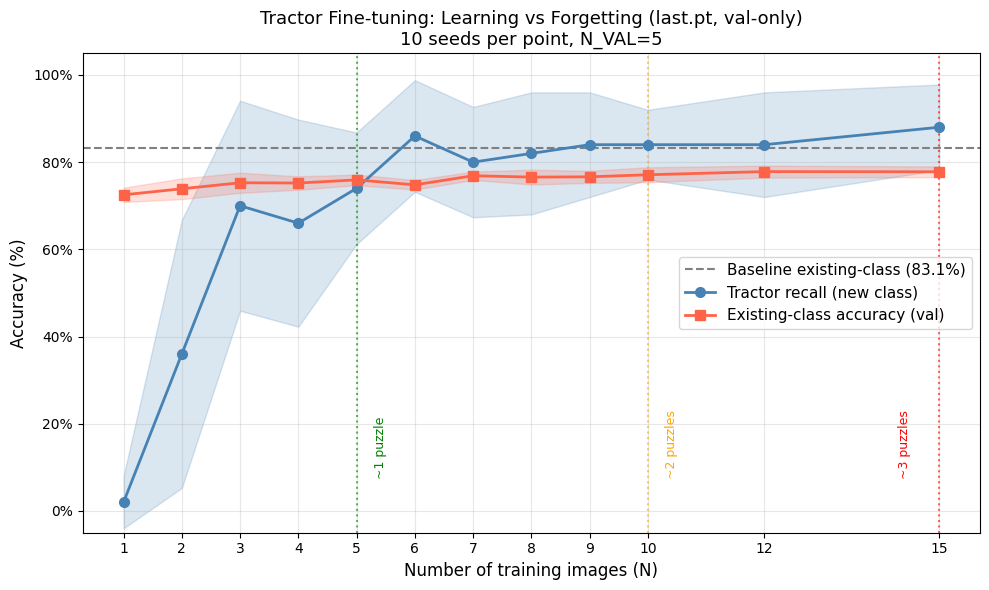

In [7]:
# ── Metrics table + plots ─────────────────────────────────────────────────────────
recall_last_mean = np.array([np.mean(last_recall[n])  for n in N_VALUES])
recall_last_std  = np.array([np.std(last_recall[n])   for n in N_VALUES])
forget_last_mean = np.array([np.mean(last_val[n])     for n in N_VALUES])
forget_last_std  = np.array([np.std(last_val[n])      for n in N_VALUES])

# ── Print metrics table ───────────────────────────────────────────────────
print(f'Tractor (last.pt, val-only)  |  Baseline existing-class: {base_acc_val:.1f}%\n')
print(f'{"N":>4} | {"Tractor recall":>17} | {"Existing-class acc":>20} | {"Forgetting":>12}')
print('-' * 65)
for i, n in enumerate(N_VALUES):
    rm, rs = recall_last_mean[i], recall_last_std[i]
    fm, fs = forget_last_mean[i], forget_last_std[i]
    forget = base_acc_val - fm
    print(f'{n:>4} | {rm:>6.1f}% +/- {rs:>4.1f}% | '
          f'{fm:>6.1f}% +/- {fs:>4.1f}%   | {forget:>+8.1f} pp')
print()

# ── Learning curve (last.pt) with puzzle annotations ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(N_VALUES, recall_last_mean, 'o-', color='steelblue', linewidth=2, markersize=7,
        label='Tractor (last.pt)', zorder=3)
ax.fill_between(N_VALUES, recall_last_mean - recall_last_std, recall_last_mean + recall_last_std,
                alpha=0.2, color='steelblue')

ax.axvline(x=5, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(5.3, 15, '~1 puzzle', fontsize=9, color='green', rotation=90)
ax.axvline(x=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(10.3, 15, '~2 puzzles', fontsize=9, color='orange', rotation=90)
ax.axvline(x=15, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(14.3, 15, '~3 puzzles', fontsize=9, color='red', rotation=90)

ax.set_xlabel('Number of training images (N)', fontsize=12)
ax.set_ylabel('Recall on held-out val images (%)', fontsize=12)
ax.set_title('Tractor Learning Curve (last.pt)\n10 seeds per point, N_VAL=5', fontsize=13)
ax.set_ylim(-5, 105)
ax.set_xticks(N_VALUES)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'tractor_er_learning_curve_lastpt.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Forgetting (last.pt, val-only) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(y=base_acc_val, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline ({base_acc_val:.1f}%)')
ax.plot(N_VALUES, forget_last_mean, 'o-', color='tomato', linewidth=2, markersize=7,
        label='After Tractor Fine-tune (last.pt)')
ax.fill_between(N_VALUES, forget_last_mean - forget_last_std, forget_last_mean + forget_last_std,
                alpha=0.2, color='tomato')
ax.set_xlabel('Number of training images (N)', fontsize=12)
ax.set_ylabel('Existing-class accuracy on val (%)', fontsize=12)
ax.set_title('Catastrophic Forgetting After Tractor Fine-tuning (last.pt, val-only)', fontsize=13)
ax.set_xticks(N_VALUES)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'tractor_er_forgetting_lastpt.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Combined: learning + forgetting on one plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(y=base_acc_val, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline existing-class ({base_acc_val:.1f}%)')

ax.plot(N_VALUES, recall_last_mean, 'o-', color='steelblue', linewidth=2, markersize=7,
        label='Tractor recall (new class)', zorder=3)
ax.fill_between(N_VALUES, recall_last_mean - recall_last_std, recall_last_mean + recall_last_std,
                alpha=0.2, color='steelblue')

ax.plot(N_VALUES, forget_last_mean, 's-', color='tomato', linewidth=2, markersize=7,
        label='Existing-class accuracy (val)', zorder=3)
ax.fill_between(N_VALUES, forget_last_mean - forget_last_std, forget_last_mean + forget_last_std,
                alpha=0.2, color='tomato')

ax.axvline(x=5, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(5.3, 8, '~1 puzzle', fontsize=9, color='green', rotation=90)
ax.axvline(x=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(10.3, 8, '~2 puzzles', fontsize=9, color='orange', rotation=90)
ax.axvline(x=15, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(14.3, 8, '~3 puzzles', fontsize=9, color='red', rotation=90)

ax.set_xlabel('Number of training images (N)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Tractor Fine-tuning: Learning vs Forgetting (last.pt, val-only)\n'
             '10 seeds per point, N_VAL=5', fontsize=13)
ax.set_ylim(-5, 105)
ax.set_xticks(N_VALUES)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'tractor_er_combined_lastpt.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Per-class accuracy breakdown (last.pt, val-only) ─────────────────────────
# Identifies which existing classes drop the most after Tractor fine-tuning.
# Re-runs inference per (N, seed), tracking per-class correctness on val.
from collections import defaultdict

# Group val images by class
val_by_class = defaultdict(list)
for img_path, true_cls in val_only_images:
    val_by_class[true_cls].append(img_path)

# ── Per-class baseline accuracy ──────────────────────────────────────────────
print('Computing per-class baseline accuracy...')
base_per_class = {}
for cls, imgs in val_by_class.items():
    if not imgs:
        base_per_class[cls] = 0.0
        continue
    correct = sum(1 for p in imgs
                  if base_model.names[base_model(p, verbose=False)[0].probs.top1] == cls)
    base_per_class[cls] = correct / len(imgs) * 100

# ── Per-class fine-tuned accuracy at each N (averaged across seeds) ──────────
print('Computing per-class fine-tuned accuracy (this takes a while)...')
per_class_after = {n: defaultdict(list) for n in N_VALUES}

for n in N_VALUES:
    for seed in range(N_SEEDS):
        w_local  = f'{RUNS_DIR}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w_backup = f'{WEIGHTS_BACKUP}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w = w_local if os.path.exists(w_local) else w_backup
        if not os.path.exists(w):
            continue
        model = YOLO(w)
        for cls, imgs in val_by_class.items():
            if not imgs:
                continue
            correct = sum(1 for p in imgs
                          if model.names[model(p, verbose=False)[0].probs.top1] == cls)
            per_class_after[n][cls].append(correct / len(imgs) * 100)
    print(f'  N={n} done')

# ── Print table for representative N values ──────────────────────────────────
N_TO_SHOW = [1, 5, 15]  # adjust if you want different N values
all_classes = sorted(val_by_class.keys())

# Sort classes by drop magnitude at the largest shown N (largest drops first)
def drop_at(cls, n):
    if not per_class_after[n].get(cls):
        return 0.0
    return base_per_class.get(cls, 0) - np.mean(per_class_after[n][cls])

sorted_classes = sorted(all_classes, key=lambda c: -drop_at(c, max(N_TO_SHOW)))

print(f'\nPer-class accuracy on val (Tractor fine-tune, last.pt)')
print(f'Sorted by drop at N={max(N_TO_SHOW)} (largest drops first)\n')

header = f'{"Class":>14} | {"#Val":>5} | {"Baseline":>9}'
for n in N_TO_SHOW:
    header += f' | {f"N={n} (drop pp)":>17}'
print(header)
print('-' * len(header))

for cls in sorted_classes:
    n_val = len(val_by_class[cls])
    base = base_per_class.get(cls, 0)
    line = f'{cls:>14} | {n_val:>5} | {base:>7.1f}%'
    for n in N_TO_SHOW:
        if per_class_after[n].get(cls):
            mean = np.mean(per_class_after[n][cls])
            drop = base - mean
            line += f' | {mean:>6.1f}% ({drop:>+5.1f})'
        else:
            line += f' | {"":>17}'
    print(line)

# ── Save per-class results to Drive ──────────────────────────────────────────
per_class_results = {
    'baseline_per_class': base_per_class,
    'per_class_after': {str(n): {cls: vals for cls, vals in d.items()}
                        for n, d in per_class_after.items()},
    'val_counts_per_class': {cls: len(imgs) for cls, imgs in val_by_class.items()},
}
save_path = os.path.join(BASE_SAVE_DIR, 'tractor_per_class_breakdown.json')
with open(save_path, 'w') as f:
    json.dump(per_class_results, f, indent=2)
print(f'\nSaved: {save_path}')


Computing per-class baseline accuracy...
Computing per-class fine-tuned accuracy (this takes a while)...
  N=1 done
  N=2 done
  N=3 done
  N=4 done
  N=5 done
  N=6 done
  N=7 done
  N=8 done
  N=9 done
  N=10 done
  N=12 done
  N=15 done

Per-class accuracy on val (Tractor fine-tune, last.pt)
Sorted by drop at N=15 (largest drops first)

         Class |  #Val |  Baseline |     N=1 (drop pp) |     N=5 (drop pp) |    N=15 (drop pp)
----------------------------------------------------------------------------------------------
         Other |    74 |    66.2% |   51.8% (+14.5) |   31.4% (+34.9) |   36.1% (+30.1)
           Car |    74 |    77.0% |   71.2% ( +5.8) |   54.9% (+22.2) |   60.3% (+16.8)
 Traffic Light |    74 |    86.5% |    1.2% (+85.3) |   70.3% (+16.2) |   75.1% (+11.4)
           Bus |    74 |    97.3% |   91.4% ( +5.9) |   86.8% (+10.5) |   90.3% ( +7.0)
        Bridge |    74 |    83.8% |   63.8% (+20.0) |   73.2% (+10.5) |   78.1% ( +5.7)
       Bicycle |    74 |    

Training set: 11149 images

Computing per-class baseline (BATCHED)...
NOTE: baseline trained on these images; accuracy is actually memorization

Computing per-class fine-tuned accuracy on TRAINING (BATCHED)...
  N=1 done
  N=2 done
  N=3 done
  N=4 done
  N=5 done
  N=6 done
  N=7 done
  N=8 done
  N=9 done
  N=10 done
  N=12 done
  N=15 done

=== Per-class accuracy on TRAINING (Tractor fine-tune, last.pt) ===
Sorted by drop at N=15 (largest drops first)
Baseline trained on these images — % is memorization, not generalization.

          Class |  #Train |  Baseline |   N=1 mean+/-std (drop pp) |   N=5 mean+/-std (drop pp) |  N=15 mean+/-std (drop pp)
----------------------------------------------------------------------------------------------------------------------------
         Other  |    1395 |    74.6% |  58.5+/- 5.7% ( +16.1) |  35.1+/-10.7% ( +39.6) |  39.2+/- 6.3% ( +35.4)
           Car  |    3504 |    87.8% |  78.0+/- 8.3% (  +9.7) |  60.3+/- 7.8% ( +27.4) |  68.0+/- 5.6% (

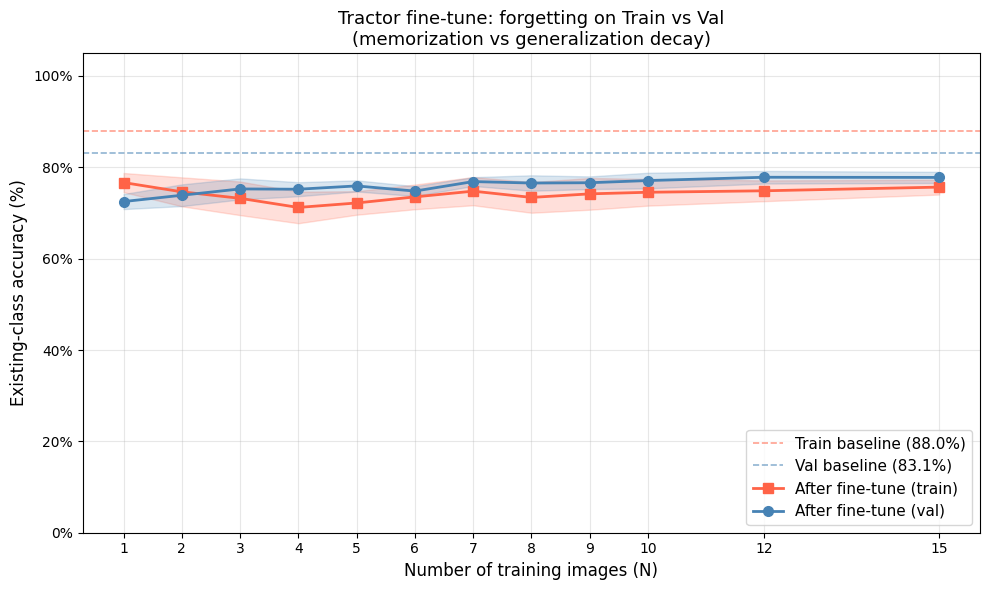

In [9]:
# ── Per-class accuracy breakdown on TRAINING set (last.pt) ──────────────────
# Baseline model was TRAINED on these images, so its baseline accuracy here
# Reflects MEMORIZATION not generalization.

from collections import defaultdict

# ── Build train-only image set (all 16 classes) ─────────────────────────────
train_only_images = []
for cls in ALL_CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for f in sorted(os.listdir(cls_dir)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            train_only_images.append((os.path.join(cls_dir, f), cls))

print(f'Training set: {len(train_only_images)} images')

train_by_class = defaultdict(list)
for img_path, true_cls in train_only_images:
    train_by_class[true_cls].append(img_path)

# Pre-build flat lists for batched inference (order preserved)
all_paths_train = []
all_truths_train = []
for cls, imgs in train_by_class.items():
    for p in imgs:
        all_paths_train.append(p)
        all_truths_train.append(cls)

# ── Per-class baseline accuracy (memorization-inflated) ─────────────────────
print('\nComputing per-class baseline (BATCHED)...')
print('NOTE: baseline trained on these images; accuracy is actually memorization')
class_correct = defaultdict(int)
class_total = defaultdict(int)
for true_cls, r in zip(all_truths_train,
                        base_model.predict(all_paths_train, batch=64, imgsz=128,
                                            verbose=False, stream=True)):
    pred = base_model.names[r.probs.top1]
    class_total[true_cls] += 1
    if pred == true_cls:
        class_correct[true_cls] += 1
base_per_class_train = {cls: (class_correct[cls] / class_total[cls] * 100
                              if class_total[cls] else 0.0)
                        for cls in train_by_class}

# ── Per-class fine-tuned accuracy at each N (batched, averaged across seeds) ─
print('\nComputing per-class fine-tuned accuracy on TRAINING (BATCHED)...')
per_class_after_train = {n: defaultdict(list) for n in N_VALUES}

for n in N_VALUES:
    for seed in range(N_SEEDS):
        w_local  = f'{RUNS_DIR}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w_backup = f'{WEIGHTS_BACKUP}/tractor_er_n{n}_seed{seed}/weights/last.pt'
        w = w_local if os.path.exists(w_local) else w_backup
        if not os.path.exists(w):
            continue
        model = YOLO(w)
        cc = defaultdict(int)
        ct = defaultdict(int)
        for true_cls, r in zip(all_truths_train,
                                model.predict(all_paths_train, batch=64, imgsz=128,
                                              verbose=False, stream=True)):
            pred = model.names[r.probs.top1]
            ct[true_cls] += 1
            if pred == true_cls:
                cc[true_cls] += 1
        for cls in train_by_class:
            if ct[cls] > 0:
                per_class_after_train[n][cls].append(cc[cls] / ct[cls] * 100)
    print(f'  N={n} done')

# ── PRINT TABLE (mean+/-std + small-sample flag) ─────────────────────────────
N_TO_SHOW = [1, 5, 15]
SMALL_SAMPLE_THRESHOLD = 30
all_classes_t = sorted(train_by_class.keys())

def drop_at_t(cls, n):
    if not per_class_after_train[n].get(cls):
        return 0.0
    return base_per_class_train.get(cls, 0) - np.mean(per_class_after_train[n][cls])

sorted_classes_t = sorted(all_classes_t, key=lambda c: -drop_at_t(c, max(N_TO_SHOW)))

print(f'\n=== Per-class accuracy on TRAINING (Tractor fine-tune, last.pt) ===')
print(f'Sorted by drop at N={max(N_TO_SHOW)} (largest drops first)')
print(f'Baseline trained on these images — % is memorization, not generalization.\n')

header = f'{"Class":>15} | {"#Train":>7} | {"Baseline":>9}'
for n in N_TO_SHOW:
    header += f' | {f"N={n} mean+/-std (drop pp)":>26}'
print(header)
print('-' * len(header))

for cls in sorted_classes_t:
    n_train = len(train_by_class[cls])
    base = base_per_class_train.get(cls, 0)
    flag = '*' if n_train < SMALL_SAMPLE_THRESHOLD else ' '
    line = f'{cls + flag:>15} | {n_train:>7} | {base:>7.1f}%'
    for n in N_TO_SHOW:
        if per_class_after_train[n].get(cls):
            mean = np.mean(per_class_after_train[n][cls])
            std  = np.std(per_class_after_train[n][cls])
            drop = base - mean
            line += f' | {mean:>5.1f}+/-{std:>4.1f}% ({drop:>+6.1f})'
        else:
            line += f' | {"":>26}'
    print(line)

print(f'\n* small sample (n_train < {SMALL_SAMPLE_THRESHOLD}): per-seed accuracy is coarse.')

# ── Aggregate (image-weighted) accuracy on Training, per N ──────────────────
total_train_imgs = sum(len(imgs) for imgs in train_by_class.values())
total_correct_base = sum(
    base_per_class_train.get(cls, 0) / 100 * len(train_by_class[cls])
    for cls in train_by_class
)
agg_baseline_train = total_correct_base / total_train_imgs * 100

agg_per_n_train = {}
for n in N_VALUES:
    seed_aggregates = []
    for seed_idx in range(N_SEEDS):
        seed_correct = 0
        seed_total = 0
        for cls in train_by_class:
            per_cls = per_class_after_train[n].get(cls, [])
            if seed_idx < len(per_cls):
                n_imgs = len(train_by_class[cls])
                seed_correct += per_cls[seed_idx] / 100 * n_imgs
                seed_total += n_imgs
        if seed_total:
            seed_aggregates.append(seed_correct / seed_total * 100)
    agg_per_n_train[n] = seed_aggregates

print(f'\n=== Aggregate accuracy on TRAINING (image-weighted) ===')
print(f'Baseline (memorized): {agg_baseline_train:.1f}%\n')
print(f'{"N":>4} | {"After fine-tune (mean+/-std)":>30} | {"Forgetting":>12}')
print('-' * 55)
for n in N_VALUES:
    aggs = agg_per_n_train[n]
    if not aggs:
        continue
    m = float(np.mean(aggs))
    s = float(np.std(aggs))
    d = agg_baseline_train - m
    print(f'{n:>4} | {m:>14.1f} +/- {s:>4.1f}% {"":>5} | {d:>+8.1f} pp')

# ── Save to Drive ────────────────────────────────────────────────────────────
per_class_train_results = {
    'baseline_per_class_train': base_per_class_train,
    'per_class_after_train': {str(n): {cls: vals for cls, vals in d.items()}
                               for n, d in per_class_after_train.items()},
    'train_counts_per_class': {cls: len(imgs) for cls, imgs in train_by_class.items()},
    'aggregate_baseline_train': agg_baseline_train,
    'aggregate_per_n_train':   {str(n): vals for n, vals in agg_per_n_train.items()},
}
save_path = os.path.join(BASE_SAVE_DIR, 'tractor_per_class_breakdown_train.json')
with open(save_path, 'w') as f:
    json.dump(per_class_train_results, f, indent=2)
print(f'\nSaved: {save_path}')

# ── Plot: train vs val forgetting trajectory ────────────────────────────────
import matplotlib.pyplot as plt

val_means_n  = [np.mean(last_val[n]) for n in N_VALUES]
val_stds_n   = [np.std(last_val[n])  for n in N_VALUES]
train_means_n = [np.mean(agg_per_n_train[n]) if agg_per_n_train[n] else 0 for n in N_VALUES]
train_stds_n  = [np.std(agg_per_n_train[n])  if agg_per_n_train[n] else 0 for n in N_VALUES]

fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(y=agg_baseline_train, color='tomato', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Train baseline ({agg_baseline_train:.1f}%)')
ax.axhline(y=base_acc_val, color='steelblue', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Val baseline ({base_acc_val:.1f}%)')

ax.plot(N_VALUES, train_means_n, 's-', color='tomato', linewidth=2, markersize=7,
        label='After fine-tune (train)', zorder=3)
ax.fill_between(N_VALUES,
                np.array(train_means_n) - np.array(train_stds_n),
                np.array(train_means_n) + np.array(train_stds_n),
                alpha=0.2, color='tomato')

ax.plot(N_VALUES, val_means_n, 'o-', color='steelblue', linewidth=2, markersize=7,
        label='After fine-tune (val)', zorder=3)
ax.fill_between(N_VALUES,
                np.array(val_means_n) - np.array(val_stds_n),
                np.array(val_means_n) + np.array(val_stds_n),
                alpha=0.2, color='steelblue')

ax.set_xlabel('Number of training images (N)', fontsize=12)
ax.set_ylabel('Existing-class accuracy (%)', fontsize=12)
ax.set_title('Tractor fine-tune: forgetting on Train vs Val\n'
             '(memorization vs generalization decay)', fontsize=13)
ax.set_xticks(N_VALUES)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'tractor_er_forgetting_train_vs_val.png'),
            dpi=150, bbox_inches='tight')
plt.show()


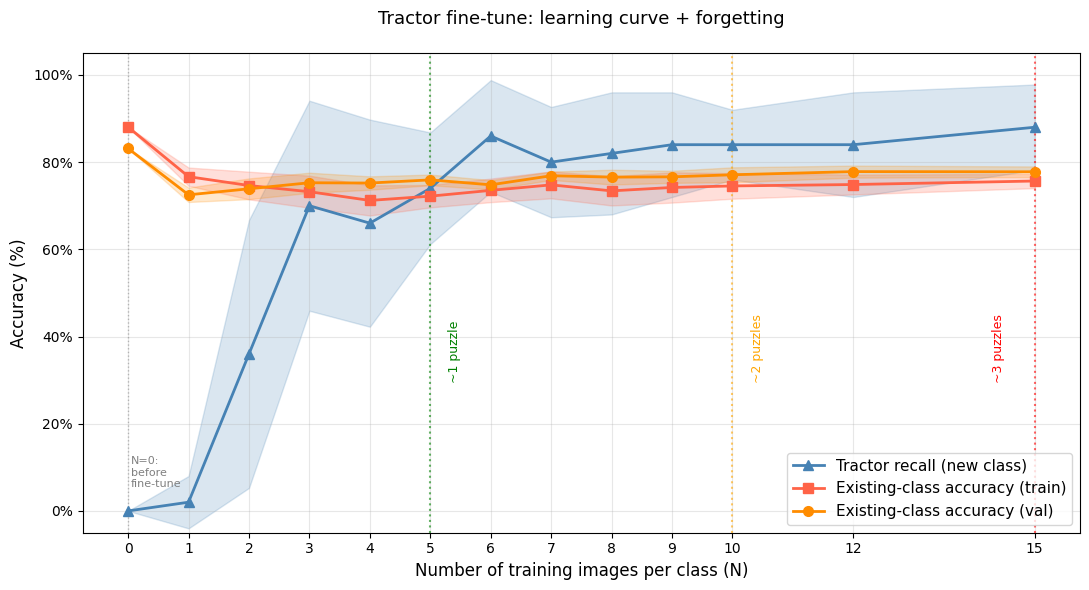

In [10]:
# ── Full summary plot: learning + forgetting with N=0 baseline ──────────────

import matplotlib.pyplot as plt

N_PLUS_ZERO = [0] + list(N_VALUES)

recall_means_z = [0.0] + [np.mean(last_recall[n]) for n in N_VALUES]
recall_stds_z  = [0.0] + [np.std(last_recall[n])  for n in N_VALUES]

train_means_z = [agg_baseline_train] + [
    np.mean(agg_per_n_train[n]) if agg_per_n_train[n] else 0 for n in N_VALUES
]
train_stds_z  = [0.0] + [
    np.std(agg_per_n_train[n]) if agg_per_n_train[n] else 0 for n in N_VALUES
]

val_means_z = [base_acc_val] + [np.mean(last_val[n]) for n in N_VALUES]
val_stds_z  = [0.0] + [np.std(last_val[n]) for n in N_VALUES]

fig, ax = plt.subplots(figsize=(11, 6))

# New-class recall
ax.plot(N_PLUS_ZERO, recall_means_z, '^-', color='steelblue', linewidth=2, markersize=7,
        label=f'Tractor recall (new class)', zorder=3)
ax.fill_between(N_PLUS_ZERO,
                np.array(recall_means_z) - np.array(recall_stds_z),
                np.array(recall_means_z) + np.array(recall_stds_z),
                alpha=0.2, color='steelblue')

# Train existing-class
ax.plot(N_PLUS_ZERO, train_means_z, 's-', color='tomato', linewidth=2, markersize=7,
        label='Existing-class accuracy (train)', zorder=3)
ax.fill_between(N_PLUS_ZERO,
                np.array(train_means_z) - np.array(train_stds_z),
                np.array(train_means_z) + np.array(train_stds_z),
                alpha=0.2, color='tomato')

# Val existing-class
ax.plot(N_PLUS_ZERO, val_means_z, 'o-', color='darkorange', linewidth=2, markersize=7,
        label='Existing-class accuracy (val)', zorder=3)
ax.fill_between(N_PLUS_ZERO,
                np.array(val_means_z) - np.array(val_stds_z),
                np.array(val_means_z) + np.array(val_stds_z),
                alpha=0.2, color='darkorange')

# Mark the baseline (N=0) with a vertical reference
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.0, alpha=0.5)
ax.text(0.05, 5, 'N=0:\nbefore\nfine-tune', fontsize=8, color='gray', va='bottom')
# ── Puzzle annotations ──────────────────────────────────────────────────────
ax.axvline(x=5, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(5.3, 30, '~1 puzzle', fontsize=9, color='green', rotation=90)
ax.axvline(x=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(10.3, 30, '~2 puzzles', fontsize=9, color='orange', rotation=90)
ax.axvline(x=15, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(14.3, 30, '~3 puzzles', fontsize=9, color='red', rotation=90)


ax.set_xlabel('Number of training images per class (N)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'Tractor fine-tune: learning curve + forgetting\n', fontsize=13)
ax.set_xticks(N_PLUS_ZERO)
ax.set_ylim(-5, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'tractor_er_full_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
